# Experiments for the paper

Every figure (PDF), table (CSV), per-repetition result and the run manifest are written to
`analysis/results/<benchmark>/<roster>/`, so the directory identifies the environment and the
file names describe the result. Duplicate the notebook and change the settings to cover another
environment.

Sections:

1. **Providers and environment**: what the platform faces and the constants of the theory.
2. **One-pass results**: the paired comparison over one pass of the benchmark.
3. **Long-horizon learning and identification**: the run continued with resampled passes.
4. **Regret and theoretical bounds**: realized regret and selections against the bounds.
5. **Payments and provider outcomes**: the payment rule and what providers receive.
6. **Run manifest**: seeds, settings and the list of outputs.
7. **Cross-environment summary**: one table over every environment that has been run.

The Best-of-N ladder is the same analysis with `ROSTER = "ladder"`.

Monetary quantities are in $10^{-6}$ USD ($\mu$USD). Four amounts stay distinct throughout:
the provider's private **generation cost**; the **query price**, generated tokens times the
provider's listed price; the provider's standing **bid**; and the **mechanism payment**, the
critical payment fixed before the outcome is revealed. The **amount paid** per query is the
mechanism payment for the mechanism and the query price for the listed-price alternatives.

In [1]:
BENCHMARK = "GSM8K"   # "GSM8K" or "GPQA"
ROSTER = "ladder"     # "full": the nine base models; "ladder": four base models at N = 1, 2, 4
T_LONG = 70_000       # rounds of the long-horizon run (sections 3 to 5)
QUICK = False         # True: three repetitions and a short horizon, to check the notebook

## Setup

Imports, the configuration, the output directory, plot style and small helpers. Nothing here
changes an experimental definition: the mechanism, policies, radii and metrics come from `cri`
and `configs/default.toml`.

In [2]:
from pathlib import Path
from dataclasses import replace
from datetime import datetime, timezone
import csv
import json
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from cri.config import load_config
from cri.experiment import prepare_environment, episode_seed, draw_seed, resolve_arm
from cri.simulate import simulate_episode
from cri.metrics import evaluate, window, theory_constants, bounds, M_count, L_count
from cri.baselines import make_policy, make_payment_rule
from cri.pricing import MODEL_PRICE_PER_1M, invoice as public_invoice
from cri.variants import parse_variant, price_rate

REPS = 3 if QUICK else 30        # paired repetitions of the one-pass experiment
LONG_REPS = 2 if QUICK else 30   # repetitions of the long-horizon run
if QUICK:
    T_LONG = min(T_LONG, 20_000)

CONFIG = load_config(ROOT / "configs/default.toml")
CONFIG = replace(CONFIG, data_root=ROOT / "datasets", rewards_root=ROOT / "rewards")
ENV = next(env for env in CONFIG.environments if env.benchmark == BENCHMARK and env.roster == ROSTER)
MASTER, MARGIN = CONFIG.master_seed, CONFIG.mechanism.margin

OUT = ROOT / "analysis/results" / BENCHMARK.lower() / ROSTER.lower()
OUT.mkdir(parents=True, exist_ok=True)
print(f"environment {ENV.id}: outputs in {OUT.relative_to(ROOT)}/")

# The policies. The first four are the fair comparison of the main text; the last one is the
# ablation that removes the mechanism's quality filter and keeps its score and payment.
POLICIES = ["mechanism", "uniform_eligible", "cheapest_rate_eligible", "cheapest_price", "no_quality_filter"]
MAIN_POLICIES = POLICIES[:4]
LONG_POLICIES = list(POLICIES)   # every routing rule is also run over the long horizon
ROLE = {
    "mechanism": "mechanism",
    "uniform_eligible": "baseline",
    "cheapest_rate_eligible": "baseline",
    "cheapest_price": "baseline",
    "no_quality_filter": "ablation",
}
STYLE = {
    "mechanism": {"label": "Mechanism", "color": "#1f6fb4", "marker": "o"},
    "uniform_eligible": {"label": "Uniform among eligible", "color": "#c9312c", "marker": "s"},
    "cheapest_rate_eligible": {"label": "Lowest listed price among eligible", "color": "#8055b8", "marker": "D"},
    "cheapest_price": {"label": "Lowest listed price, no quality filter", "color": "#2e9e4f", "marker": "v"},
    "no_quality_filter": {"label": "No quality filter", "color": "#dcac1b", "marker": "X"},
}
HOLLOW = {"cheapest_rate_eligible", "cheapest_price"}   # hollow markers keep coinciding points visible
COLOR_ISTAR, COLOR_QUALIFIED, COLOR_UNQUALIFIED = "#2e9e4f", "#3b7dd8", "#e6862a"

PANEL = (3.2, 2.15)   # inches; a panel at 0.48 of a 6.5 in text width prints at its natural size

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9, "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.18, "pdf.fonttype": 42,
})


from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.transforms import blended_transform_factory


def finish(fig, name, *, title, legend=True, rect=None):
    # Save the panel as its own PDF without a title or legend (the paper composes panels and
    # adds a shared legend). For the notebook display only, add the title and put the legend
    # outside the axes, widening the figure so the panel itself stays as saved.
    fig.tight_layout(rect=rect)
    path = OUT / f"{name}.pdf"
    fig.savefig(path, metadata={"Creator": "paper_experiments.ipynb"})
    print("figure:", path.relative_to(ROOT))
    ax = fig.axes[0]
    ax.set_title(title, loc="left", fontsize=9)
    if legend and ax.get_legend_handles_labels()[0]:
        width, height = fig.get_size_inches()
        fig.set_size_inches(width + 2.6, height)
        fig.subplots_adjust(right=width / (width + 2.6))
        ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
    plt.show()
    plt.close(fig)


def save_legend(entries, name, *, ncol):
    # A standalone legend PDF for a group of panels; entries are (handle, label) pairs.
    fig = plt.figure(figsize=(0.5, 0.5))
    legend = fig.legend([h for h, _ in entries], [l for _, l in entries], loc="center", ncol=ncol,
                        frameon=False, borderaxespad=0, columnspacing=1.4, handlelength=2.2)
    fig.canvas.draw()
    box = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    path = OUT / f"legend_{name}.pdf"
    fig.savefig(path, bbox_inches=box.expanded(1.03, 1.15), metadata={"Creator": "paper_experiments.ipynb"})
    plt.close(fig)
    print("legend:", path.relative_to(ROOT))


def hline(ax, value, label, *, style="--", color="#222", where=0.985, above=True):
    # A horizontal reference line annotated inside the panel instead of in the legend.
    ax.axhline(value, color=color, linestyle=style, linewidth=1.0)
    ax.text(where, value, label, transform=blended_transform_factory(ax.transAxes, ax.transData),
            ha="left" if where < 0.5 else "right", va="bottom" if above else "top", fontsize=7, color=color,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.2}, zorder=6)


def policy_line(name, **kwargs):
    return Line2D([], [], color=STYLE[name]["color"], linewidth=2.2 if name == "mechanism" else 1.35, **kwargs)


def policy_marker(name):
    style = STYLE[name]
    return Line2D([], [], linestyle="none", marker=style["marker"], color=style["color"],
                  markerfacecolor="none" if name in HOLLOW else style["color"], markeredgewidth=1.4, markersize=7)


VLINES = [(Line2D([], [], color="#666", linestyle=":", linewidth=1), "One pass over the benchmark"),
          (Line2D([], [], color="#888", linestyle="--", linewidth=1), "Identification horizon $n + 2B_{\\mathrm{id}}$")]


def _cell(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, (np.ndarray, dict, list, tuple)):
        return json.dumps(value.tolist() if isinstance(value, np.ndarray) else value, separators=(",", ":"))
    return value


def save_table(header, rows, name):
    path = OUT / f"{name}.csv"
    with path.open("w", newline="") as handle:
        csv.writer(handle).writerows([header, *([_cell(v) for v in row] for row in rows)])
    print("table:", path.relative_to(ROOT))


def save_records(records, name):
    # One CSV row per record; used for the per-repetition results.
    path = OUT / f"{name}.csv"
    header = list(dict.fromkeys(key for record in records for key in record))
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=header)
        writer.writeheader()
        for record in records:
            writer.writerow({key: _cell(record.get(key)) for key in header})
    print("results:", path.relative_to(ROOT))


def show(header, rows):
    fmt = lambda v: f"{v:.4f}" if isinstance(v, float) else str(v)
    text = [[fmt(v) for v in row] for row in rows]
    widths = [max(len(str(h)), *(len(row[i]) for row in text)) for i, h in enumerate(header)]
    print("  ".join(str(h).rjust(w) for h, w in zip(header, widths)))
    for row in text:
        print("  ".join(v.rjust(w) for v, w in zip(row, widths)))


def mean_ci(values):
    # Mean and normal-approximation 95% half-width across repetitions.
    values = np.asarray(values, dtype=float)
    half = 1.96 * values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0
    return float(values.mean()), float(half)


def sd(values):
    values = np.asarray(values, dtype=float)
    return float(values.std(ddof=1)) if len(values) > 1 else 0.0


def git_value(*args):
    proc = subprocess.run(["git", *args], cwd=ROOT, text=True, capture_output=True)
    return proc.stdout.strip() if proc.returncode == 0 else None

environment GSM8K-ladder: outputs in analysis/results/gsm8k/ladder/


## 1. Providers and environment

The environment is the roster, the benchmark and the quality threshold $\Theta$. This section
records what the platform faces: each provider's quality $q_i$, listed price and expected
generation cost $\bar c_i$, the qualified set $Q$, the target $i^*$, and the constants of the
theory ($C_{\max}$, the per-provider bounds $M(\varepsilon_j)$ and $L(\Delta_j)$, $B_{\mathrm{id}}$
and the identification horizon $n + 2B_{\mathrm{id}}$). The margin is used only to construct the
simulated generation costs from the recorded token counts; the mechanism never sees it.

In [3]:
# Load the data, the ground truth and the radii; write the environment constants.
DATA, TRUTH, RADII = prepare_environment(CONFIG, ENV)
MODELS = list(TRUTH.roster)
N = len(MODELS)
ONE_PASS = DATA.n_questions                      # rounds in one pass over the benchmark
assert ENV.t_max == ONE_PASS, (ENV.t_max, ONE_PASS)
assert T_LONG > ONE_PASS, "T_LONG must exceed one pass"
TC = theory_constants(TRUTH, RADII, stream=T_LONG)
for model in MODELS:
    assert np.isclose(TRUTH.price[model], (1 + MARGIN) * TRUTH.c[model])

lowest_rate = min(price_rate(m) for m in MODELS)
LOWEST_PRICE = [m for m in MODELS if price_rate(m) == lowest_rate]      # ties are possible
LOWEST_PRICE_QUALIFIED = min(TRUTH.qualified, key=price_rate)

rows = [
    ["benchmark", BENCHMARK],
    ["roster", ROSTER],
    ["providers n", N],
    ["questions (one pass T)", ONE_PASS],
    ["generations per question", DATA.samples_per_question],
    ["Theta", ENV.theta],
    ["qualified providers |Q|", len(TRUTH.qualified)],
    ["i*", TRUTH.istar],
    ["c_i* (expected generation cost of i*)", TRUTH.c_star],
    ["expected query price of i*", TRUTH.price[TRUTH.istar]],
    ["c^(2) (second-lowest qualified cost)", TRUTH.c_second],
    ["Delta = c^(2) - c_i*", TRUTH.delta_gap],
    ["lowest-listed-price provider(s)", " / ".join(LOWEST_PRICE)],
    ["lowest-listed-price provider qualified?", all(m in TRUTH.qualified for m in LOWEST_PRICE)],
    ["lowest-listed-price provider is i*?", LOWEST_PRICE == [TRUTH.istar]],
    ["lowest-listed-price qualified provider", LOWEST_PRICE_QUALIFIED],
    ["its expected generation cost", TRUTH.c[LOWEST_PRICE_QUALIFIED]],
    ["C_max", RADII.c_max],
    ["delta", RADII.delta],
    ["gamma", RADII.gamma],
    ["margin (cost construction only)", MARGIN],
    ["sum of M(eps_j)", TC.sum_M],
    ["sum of L(Delta_j)", TC.sum_L],
    ["B_id", TC.B_id],
    ["identification horizon n + 2 B_id", TC.need],
    ["long-horizon rounds T_LONG", T_LONG],
    ["identification horizon within T_LONG?", TC.reachable],
]
show(["quantity", "value"], rows)
save_table(["quantity", "value"], rows, "environment")

                               quantity                      value
                              benchmark                      GSM8K
                                 roster                     ladder
                            providers n                         12
                 questions (one pass T)                       1319
               generations per question                        128
                                  Theta                     0.8050
                qualified providers |Q|                          3
                                     i*                 Qwen2.5-7B
  c_i* (expected generation cost of i*)                    34.3722
             expected query price of i*                    42.9652
   c^(2) (second-lowest qualified cost)                    68.7444
                   Delta = c^(2) - c_i*                    34.3722
        lowest-listed-price provider(s)  Llama-3.2-1B / Qwen2-1.5B
lowest-listed-price provider qualified?                      F

In [4]:
# One row per provider: listed price, tokens, expected query price and cost, quality, and the
# gap and selection bound the theory assigns to it.
def provider_gap(model):
    if model == TRUTH.istar:
        return "", "", ""
    if model in TRUTH.eps:
        return "eps_j = Theta - q_j", TRUTH.eps[model], M_count(TRUTH.eps[model], N, RADII.delta)
    return "Delta_j = c_j - c_i*", TRUTH.delta_j[model], L_count(TRUTH.delta_j[model], N, RADII.delta, RADII.c_max, RADII.gamma)


header = [
    "provider", "base model", "N", "listed price (USD per 1M tokens)", "mean tokens per query",
    "expected query price", "expected generation cost", "quality", "qualified?", "role",
    "gap type", "gap", "selection bound (M or L)",
]
rows = []
for model in sorted(MODELS, key=lambda m: TRUTH.c[m]):
    variant = parse_variant(model)
    gap_type, gap, bound = provider_gap(model)
    rows.append([
        model, variant.base, variant.n, MODEL_PRICE_PER_1M[variant.base],
        variant.n * float(DATA.records[variant.base].num_tokens.mean()),
        TRUTH.price[model], TRUTH.c[model], TRUTH.q[model], model in TRUTH.qualified,
        "i*" if model == TRUTH.istar else "qualified" if model in TRUTH.qualified else "unqualified",
        gap_type, gap, bound,
    ])
show(header, rows)
save_table(header, rows, "providers")

      provider    base model  N  listed price (USD per 1M tokens)  mean tokens per query  expected query price  expected generation cost  quality  qualified?         role              gap type       gap  selection bound (M or L)
    Qwen2-1.5B    Qwen2-1.5B  1                            0.1000               189.2918               18.9292                   15.1433   0.5745       False  unqualified   eps_j = Theta - q_j    0.2305                      1159
  Llama-3.2-1B  Llama-3.2-1B  1                            0.1000               198.8200               19.8820                   15.9056   0.3645       False  unqualified   eps_j = Theta - q_j    0.4405                       264
    Llama-3-8B    Llama-3-8B  1                            0.1455               191.9969               27.9355                   22.3484   0.6495       False  unqualified   eps_j = Theta - q_j    0.1555                      2809
  Qwen2-1.5B@2    Qwen2-1.5B  2                            0.1000               378.

figure: analysis/results/gsm8k/ladder/quality_vs_query_price.pdf


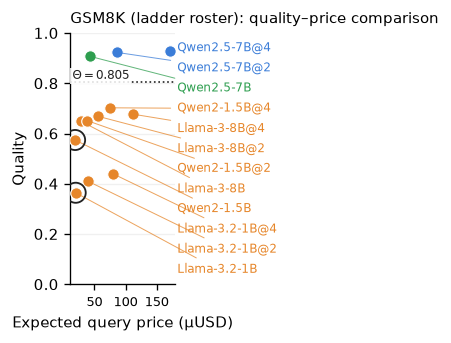

legend: analysis/results/gsm8k/ladder/legend_landscape.pdf


In [5]:
# Figure: quality against expected query price, one point per provider. The legend is a separate PDF.
fig, ax = plt.subplots(figsize=(3.4, 2.8))
ordered = sorted(MODELS, key=lambda m: TRUTH.q[m])
label_y = np.linspace(0.06, 0.94, len(ordered))
for rank, model in enumerate(ordered):
    color = COLOR_ISTAR if model == TRUTH.istar else COLOR_QUALIFIED if model in TRUTH.qualified else COLOR_UNQUALIFIED
    ax.scatter(TRUTH.price[model], TRUTH.q[model], s=48, color=color, edgecolor="white", linewidth=0.7, zorder=3)
    ax.annotate(
        model, (TRUTH.price[model], TRUTH.q[model]), xytext=(1.02, label_y[rank]), textcoords=ax.transAxes,
        color=color, va="center", fontsize=7.2, zorder=4, clip_on=False,
        arrowprops={"arrowstyle": "-", "color": color, "lw": 0.6, "alpha": 0.75},
    )
    if model in LOWEST_PRICE:
        ax.scatter(TRUTH.price[model], TRUTH.q[model], s=145, facecolor="none", edgecolor="#222", linewidth=1.1, zorder=5)
hline(ax, ENV.theta, f"$\\Theta = {ENV.theta}$", style=":", where=0.02)
ax.set_ylim(0, min(1.0, 1.14 * max(TRUTH.q.values()) + 0.02))
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.tick_params(axis="x", labelsize=8)
ax.set_xlabel("Expected query price (µUSD)")
ax.set_ylabel("Quality")
finish(fig, "quality_vs_query_price", title=f"{BENCHMARK} ({ROSTER} roster): quality–price comparison", legend=False, rect=(0, 0, 0.74, 1))

save_legend([
    (Line2D([], [], linestyle="none", marker="o", color=COLOR_ISTAR, markersize=7), "$i^*$"),
    (Line2D([], [], linestyle="none", marker="o", color=COLOR_QUALIFIED, markersize=7), "Other qualified provider"),
    (Line2D([], [], linestyle="none", marker="o", color=COLOR_UNQUALIFIED, markersize=7), "Unqualified provider"),
    (Line2D([], [], linestyle="none", marker="o", markerfacecolor="none", markeredgecolor="#222", markersize=10), "Lowest listed price"),
], "landscape", ncol=4)

## 2. One-pass results

Each repetition plays the benchmark once. Within a repetition every policy receives the same
question order, initialization order, tie draws and provider outcomes, so the differences below
are paired. One pass is far shorter than the identification horizon, so this is a finite-horizon
comparison of routing rules, not an identification experiment.

The policies are the mechanism, three alternatives a platform could deploy with the same or less
information, and one ablation:

- **Mechanism**: bids, graded outcomes and the online quality filter; pays the critical payment.
- **Uniform among eligible**: the same quality filter, a uniform draw inside it; no bids or prices.
- **Lowest listed price among eligible**: the same quality filter and the listed prices.
- **Lowest listed price, no quality filter**: listed prices only.
- **No quality filter** (ablation): the mechanism's score and payment without the filter.

The three alternatives are treated as listed-price APIs: the amount they pay is the query price
of the selected provider. Eligible means not yet ruled out by the quality filter, not certified
qualified.

In [6]:
# The policies, the information each one uses, and what it pays.
header = ["policy", "label", "role", "information used", "amount paid"]
rows = [
    ["mechanism", STYLE["mechanism"]["label"], ROLE["mechanism"],
     "graded outcomes, standing bids, Theta, confidence radii, C_max", "critical payment"],
    ["uniform_eligible", STYLE["uniform_eligible"]["label"], ROLE["uniform_eligible"],
     "graded outcomes and the online quality filter", "query price"],
    ["cheapest_rate_eligible", STYLE["cheapest_rate_eligible"]["label"], ROLE["cheapest_rate_eligible"],
     "graded outcomes, the online quality filter and listed prices", "query price"],
    ["cheapest_price", STYLE["cheapest_price"]["label"], ROLE["cheapest_price"],
     "listed prices only", "query price"],
    ["no_quality_filter", STYLE["no_quality_filter"]["label"], ROLE["no_quality_filter"],
     "standing bids, Theta, confidence radii, C_max; no quality filter", "critical payment"],
]
show(header, rows)
save_table(header, rows, "policies")

                policy                                   label       role                                                  information used       amount paid
             mechanism                               Mechanism  mechanism    graded outcomes, standing bids, Theta, confidence radii, C_max  critical payment
      uniform_eligible                  Uniform among eligible   baseline                     graded outcomes and the online quality filter       query price
cheapest_rate_eligible      Lowest listed price among eligible   baseline      graded outcomes, the online quality filter and listed prices       query price
        cheapest_price  Lowest listed price, no quality filter   baseline                                                listed prices only       query price
     no_quality_filter                       No quality filter   ablation  standing bids, Theta, confidence radii, C_max; no quality filter  critical payment
table: analysis/results/gsm8k/ladder/policies.csv


In [7]:
# Run the paired one-pass experiment: REPS repetitions x POLICIES. One record per episode.
def episode_record(name, rep, seed, arm, episode):
    metrics = evaluate(episode.log, TRUTH, arm.radii)
    post = evaluate(window(episode.log, start=N + 1), TRUTH, arm.radii)   # after initialization
    columns = episode.log.columns()
    main = columns["phase"] == "main"
    paid = metrics.total_payment is not None
    amount_paid = metrics.total_payment if paid else metrics.total_invoice
    amount_paid_post = post.total_payment if paid else post.total_invoice

    # Payment bounds of the payment-bounds lemma, checked round by round.
    rho = np.array([arm.radii.rho(int(m)) for m in columns["m_winner"][main]])
    winner_cost = np.array([TRUTH.c[m] for m in columns["winner"][main]])
    lower = np.maximum(0.0, winner_cost - rho)
    upper = np.minimum(arm.radii.c_max, TRUTH.c_second + rho)
    payment = columns["payment"][main].astype(float)
    bound_violations = int(np.sum((payment < lower - 1e-9) | (payment > upper + 1e-9))) if paid else None

    assert np.isclose(metrics.total_invoice, (1 + MARGIN) * metrics.total_cost)
    return {
        "environment": ENV.id,
        "policy": name,
        "role": ROLE[name],
        "repetition": rep,
        "seed": seed,
        "rounds": metrics.rounds,
        "termination": episode.termination,
        "amount_paid_basis": "critical payment" if paid else "query price",
        "unqualified_share": metrics.unqualified_rounds / metrics.rounds,
        "unqualified_share_post_init": post.unqualified_rounds / post.rounds,
        "quality_regret_per_round": metrics.quality_regret / metrics.rounds,
        "generation_regret_per_round": metrics.generation_regret / metrics.rounds,
        "realized_accuracy": metrics.realized_accuracy,
        "istar_share": metrics.istar_share,
        "generation_cost_per_query": metrics.total_cost / metrics.rounds,
        "generation_cost_per_query_post_init": post.total_cost / post.rounds,
        "query_price_per_query": metrics.total_invoice / metrics.rounds,
        "query_price_per_query_post_init": post.total_invoice / post.rounds,
        "mean_winning_bid_post_init": float(np.nanmean(columns["bid_winner"][main].astype(float))),
        "mechanism_payment_per_query": metrics.total_payment / metrics.rounds if paid else None,
        "mechanism_payment_per_query_post_init": post.total_payment / post.rounds if paid else None,
        "amount_paid_per_query": amount_paid / metrics.rounds,
        "amount_paid_per_query_post_init": amount_paid_post / post.rounds,
        "excess_payment_per_round": metrics.excess_payment / metrics.rounds if paid else None,
        "excess_payment_per_round_post_init": post.excess_payment / post.rounds if paid else None,
        "mean_provider_payoff": float(np.mean(list(metrics.provider_payoff.values()))) if paid else None,
        "min_provider_payoff": metrics.min_provider_payoff,
        "critical_below_bid_rounds": metrics.critical_below_bid_rounds,
        "payment_bound_violations": bound_violations,
        "good_event_holds": metrics.good_event_holds,
        "good_event_violations": metrics.good_event_violations,
        "selection_counts": metrics.selection_counts,
        "provider_payoff": metrics.provider_payoff,
    }


ONE = []
AUDIT = {}    # round logs of the first repetition, kept for inspection
for rep in range(REPS):
    seed, dseed = episode_seed(MASTER, ENV.id, rep), draw_seed(MASTER, ENV.id)
    for name in POLICIES:
        arm = resolve_arm(name, CONFIG, TRUTH, RADII)
        episode = simulate_episode(
            DATA, MODELS, theta=ENV.theta, radii=arm.radii, estimator=arm.estimator, margin=MARGIN,
            t_max=ONE_PASS, seed=seed, draw_seed=dseed, repetition=rep,
            policy=make_policy(arm.policy_name, TRUTH), payment_rule=make_payment_rule(arm.payment_name),
        )
        ONE.append(episode_record(name, rep, seed, arm, episode))
        if rep == 0:
            AUDIT[name] = episode.log.columns()
print(f"{ENV.id}: {REPS} repetitions x {len(POLICIES)} policies done")
save_records(ONE, "one_pass_per_repetition")


def pick(records, policy, key):
    return np.array([r[key] for r in records if r["policy"] == policy], dtype=float)

GSM8K-ladder: 30 repetitions x 5 policies done
results: analysis/results/gsm8k/ladder/one_pass_per_repetition.csv


In [8]:
# Table: one-pass outcomes per policy, mean, standard deviation and 95% half-width over repetitions.
OUTCOME_METRICS = [
    "unqualified_share", "quality_regret_per_round", "generation_regret_per_round", "realized_accuracy",
    "istar_share", "generation_cost_per_query", "query_price_per_query", "amount_paid_per_query",
]
header = ["policy", "role", "amount paid basis"]
for key in OUTCOME_METRICS:
    header += [f"{key} mean", f"{key} sd", f"{key} 95% half-width"]
rows = []
for name in POLICIES:
    basis = next(r["amount_paid_basis"] for r in ONE if r["policy"] == name)
    row = [name, ROLE[name], basis]
    for key in OUTCOME_METRICS:
        values = pick(ONE, name, key)
        mean, half = mean_ci(values)
        row += [mean, sd(values), half]
    rows.append(row)
show(["policy", *OUTCOME_METRICS], [[row[0], *row[3::3]] for row in rows])
save_table(header, rows, "one_pass_outcomes")

                policy  unqualified_share  quality_regret_per_round  generation_regret_per_round  realized_accuracy  istar_share  generation_cost_per_query  query_price_per_query  amount_paid_per_query
             mechanism             0.7898                    0.1494                       9.4076             0.6756       0.1402                    37.7971                47.2463                40.3858
      uniform_eligible             0.6897                    0.1260                      24.8131             0.7112       0.1032                    55.3458                69.1822                69.1822
cheapest_rate_eligible             0.4461                    0.0870                       0.1958             0.7748       0.5524                    28.1754                35.2193                35.2193
        cheapest_price             0.9977                    0.3325                       0.1958             0.4769       0.0008                    15.8379                19.7973              

In [9]:
# Table: mechanism minus each other policy, paired within repetitions, with 95% half-widths.
COMPARE_METRICS = [
    "unqualified_share", "quality_regret_per_round", "generation_regret_per_round",
    "generation_cost_per_query", "amount_paid_per_query", "istar_share",
]
header = ["baseline", "role", *[f"{key} difference" for key in COMPARE_METRICS], *[f"{key} 95% half-width" for key in COMPARE_METRICS]]
rows = []
for name in POLICIES[1:]:
    stats = [mean_ci(pick(ONE, "mechanism", key) - pick(ONE, name, key)) for key in COMPARE_METRICS]
    rows.append([name, ROLE[name], *[s[0] for s in stats], *[s[1] for s in stats]])
show(["baseline", *COMPARE_METRICS], [row[:1] + row[2:2 + len(COMPARE_METRICS)] for row in rows])
save_table(header, rows, "one_pass_paired_differences")

              baseline  unqualified_share  quality_regret_per_round  generation_regret_per_round  generation_cost_per_query  amount_paid_per_query  istar_share
      uniform_eligible             0.1002                    0.0234                     -15.4055                   -17.5487               -28.7964       0.0369
cheapest_rate_eligible             0.3437                    0.0623                       9.2118                     9.6217                 5.1666      -0.4122
        cheapest_price            -0.2079                   -0.1832                       9.2118                    21.9592                20.5885       0.1394
     no_quality_filter            -0.0651                   -0.0711                       1.8416                     4.3425                 4.3443       0.0491
table: analysis/results/gsm8k/ladder/one_pass_paired_differences.csv


figure: analysis/results/gsm8k/ladder/one_pass_quality_regret_vs_generation_cost.pdf


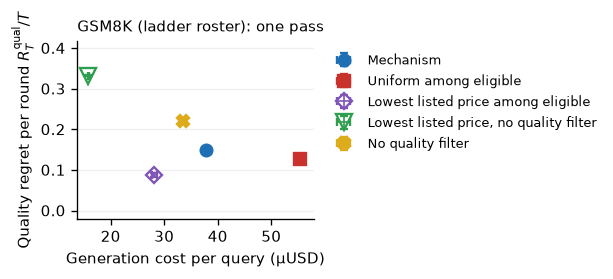

legend: analysis/results/gsm8k/ladder/legend_policies_markers.pdf


In [10]:
# Figure: quality regret per round against generation cost per query, every routing rule.
MARKER_SIZE = {"mechanism": 7, "uniform_eligible": 7, "cheapest_rate_eligible": 7, "cheapest_price": 10, "no_quality_filter": 7}


def one_pass_point(ax, name, x_key, y_key):
    style = STYLE[name]
    x, xerr = mean_ci(pick(ONE, name, x_key))
    y, yerr = mean_ci(pick(ONE, name, y_key))
    ax.errorbar(
        x, y, xerr=xerr, yerr=yerr, fmt=style["marker"], color=style["color"],
        markerfacecolor="none" if name in HOLLOW else style["color"], markeredgewidth=1.4,
        markersize=MARKER_SIZE[name], capsize=2.5, elinewidth=1, label=style["label"], zorder=4,
    )
    return y + yerr


fig, ax = plt.subplots(figsize=PANEL)
top = max(one_pass_point(ax, name, "generation_cost_per_query", "quality_regret_per_round") for name in POLICIES)
ax.set_xlabel("Generation cost per query (µUSD)")
ax.set_ylabel("Quality regret per round $R_T^{\\mathrm{qual}}/T$")
ax.set_ylim(-0.06 * top, 1.25 * top)
finish(fig, "one_pass_quality_regret_vs_generation_cost", title=f"{BENCHMARK} ({ROSTER} roster): one pass")

save_legend([(policy_marker(name), STYLE[name]["label"]) for name in POLICIES], "policies_markers", ncol=2)

figure: analysis/results/gsm8k/ladder/one_pass_quality_vs_amount_paid.pdf


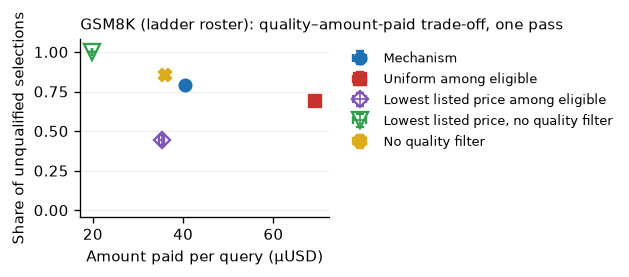

In [11]:
# Figure: share of unqualified selections against the amount paid per query, every routing rule.
fig, ax = plt.subplots(figsize=PANEL)
for name in POLICIES:
    one_pass_point(ax, name, "amount_paid_per_query", "unqualified_share")
ax.set_xlabel("Amount paid per query (µUSD)")
ax.set_ylabel("Share of unqualified selections")
ax.set_ylim(-0.04, 1.08)
finish(fig, "one_pass_quality_vs_amount_paid", title=f"{BENCHMARK} ({ROSTER} roster): quality–amount-paid trade-off, one pass")

figure: analysis/results/gsm8k/ladder/one_pass_mechanism_selection_shares.pdf


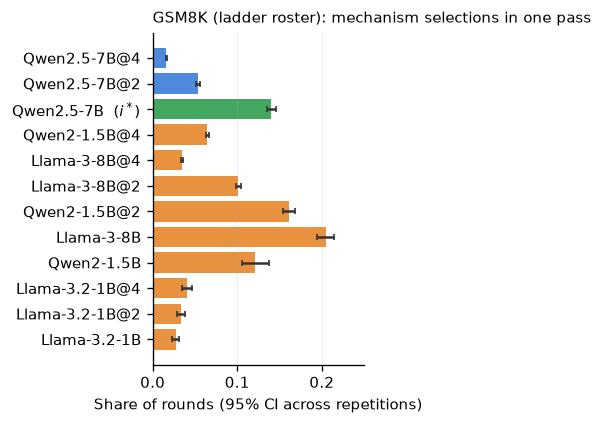

In [12]:
# Figure: where the mechanism's one-pass rounds went, per provider. Colour marks the true
# qualification (green i*, blue qualified, orange unqualified); the mechanism never sees it.
ordered = sorted(MODELS, key=lambda m: TRUTH.q[m])
means, halves = [], []
for model in ordered:
    shares = [r["selection_counts"][model] / r["rounds"] for r in ONE if r["policy"] == "mechanism"]
    mean, half = mean_ci(shares)
    means.append(mean)
    halves.append(half)
colors = [COLOR_ISTAR if m == TRUTH.istar else COLOR_QUALIFIED if m in TRUTH.qualified else COLOR_UNQUALIFIED for m in ordered]
labels = [m + ("  ($i^*$)" if m == TRUTH.istar else "") for m in ordered]

fig, ax = plt.subplots(figsize=(PANEL[0], 0.22 * N + 0.8))
y = np.arange(N)
ax.barh(y, means, xerr=halves, color=colors, alpha=0.9, ecolor="#333", capsize=2)
ax.set_yticks(y, labels)
ax.set_xlabel("Share of rounds (95% CI across repetitions)")
ax.set_xlim(0, max(means) * 1.22)
ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)
finish(fig, "one_pass_mechanism_selection_shares", title=f"{BENCHMARK} ({ROSTER} roster): mechanism selections in one pass", legend=False)

## 3. Long-horizon learning and identification

The run is continued to `T_LONG` rounds. After the first pass, each further pass reshuffles the
same questions and draws fresh generations from their recorded pools, so the results are
conditional on the benchmark. All five routing rules are compared: the mechanism, uniform
selection among eligible providers, the lowest listed price among eligible providers, the lowest
listed price without a quality filter, and the no-quality-filter ablation. Trajectories show the median over repetitions with a 10–90% band. "Rolling" means a
window of one pass. Identification is reported as the fraction of repetitions in which $i^*$ is
the unique provider with the most selections.

In [13]:
# Checkpoints, the evaluation grid and the rolling window.
CHECKPOINTS = sorted({N, ONE_PASS, 5_000, 10_000, 25_000, 50_000, TC.need + 1, T_LONG} & set(range(1, T_LONG + 1)))
GRID = np.unique(np.concatenate([np.round(np.logspace(np.log10(N), np.log10(T_LONG), 160)).astype(int), CHECKPOINTS]))
GRID_INDEX = GRID - 1
INDEX = {model: j for j, model in enumerate(MODELS)}
ISTAR = INDEX[TRUTH.istar]
QUALIFIED = np.array([INDEX[m] for m in TRUTH.qualified])
Q_VEC = np.array([TRUTH.q[m] for m in MODELS])
C_VEC = np.array([TRUTH.c[m] for m in MODELS])
RATE_VEC = np.array([public_invoice(m, 1) for m in MODELS])   # listed price per token


def rolling(cumulative, valid=None):
    # Mean over the last pass; over all rounds so far before one pass is complete. `valid` is the
    # cumulative count of rounds that enter the mean; by default every round does.
    if valid is None:
        valid = np.arange(1, len(cumulative) + 1)
    complete = GRID_INDEX >= ONE_PASS
    start = np.maximum(GRID_INDEX - ONE_PASS, 0)
    total = cumulative[GRID_INDEX] - np.where(complete, cumulative[start], 0.0)
    count = valid[GRID_INDEX] - np.where(complete, valid[start], 0)
    return np.divide(total, count, out=np.full(len(GRID), np.nan), where=count > 0)


AFTER_INIT = np.arange(T_LONG) >= N   # initialization pays C_max, so payment quantities exclude it


def rolling_after_init(values):
    return rolling(np.cumsum(np.where(AFTER_INIT, values, 0.0)), np.cumsum(AFTER_INIT))


print(f"{ENV.id}: {T_LONG:,} rounds = {-(-T_LONG // ONE_PASS)} passes; "
      f"identification horizon n + 2 B_id = {TC.need:,}; within T_LONG: {TC.reachable}")
print("checkpoints:", CHECKPOINTS)

GSM8K-ladder: 70,000 rounds = 54 passes; identification horizon n + 2 B_id = 58,300; within T_LONG: True
checkpoints: [12, 1319, 5000, 10000, 25000, 50000, 58301, 70000]


In [14]:
# Run the long-horizon episodes and keep every trajectory on the grid.
LONG = {name: [] for name in LONG_POLICIES}
for rep in range(LONG_REPS):
    seed, dseed = episode_seed(MASTER, ENV.id, rep), draw_seed(MASTER, ENV.id)
    for name in LONG_POLICIES:
        arm = resolve_arm(name, CONFIG, TRUTH, RADII)
        episode = simulate_episode(
            DATA, MODELS, theta=ENV.theta, radii=arm.radii, estimator=arm.estimator, margin=MARGIN,
            t_max=T_LONG, seed=seed, draw_seed=dseed, repetition=rep, resample=True,
            policy=make_policy(arm.policy_name, TRUTH), payment_rule=make_payment_rule(arm.payment_name),
        )
        if episode.rounds != T_LONG:
            raise RuntimeError(f"{name}, repetition {rep} halted at {episode.rounds}")
        columns = episode.log.columns()
        winners = np.fromiter((INDEX[m] for m in columns["winner"]), dtype=int, count=T_LONG)
        rounds = np.arange(1, T_LONG + 1)
        counts = np.stack([np.cumsum(winners == j) for j in range(N)], axis=1)
        cum_istar = counts[:, ISTAR]
        cum_unqualified = rounds - counts[:, QUALIFIED].sum(axis=1)
        cum_quality_regret = np.cumsum(np.maximum(ENV.theta - Q_VEC[winners], 0.0))
        cum_generation_regret = np.cumsum(np.maximum(C_VEC[winners] - TRUTH.c_star, 0.0))
        cum_cost = np.cumsum(columns["cost"])
        cum_price = np.cumsum(columns["num_tokens"].astype(float) * RATE_VEC[winners])
        payment = columns["payment"].astype(float)
        paid = not np.isnan(payment).any()
        amount = payment if paid else columns["num_tokens"].astype(float) * RATE_VEC[winners]
        cum_paid = np.cumsum(amount)
        bid = np.nan_to_num(columns["bid_winner"].astype(float))   # NaN in the initialization rounds
        at_grid = counts[GRID_INDEX]
        leader = at_grid.max(axis=1)
        audit = evaluate(episode.log, TRUTH, arm.radii) if paid else None
        if paid:   # the payment bounds of the payment-bounds lemma, round by round, kept on the grid
            rho = np.array([arm.radii.rho(int(m)) if m > 0 else np.nan for m in columns["m_winner"]])
            bound_lower = np.maximum(0.0, C_VEC[winners] - rho)[GRID_INDEX]
            bound_upper = np.minimum(arm.radii.c_max, TRUTH.c_second + rho)[GRID_INDEX]
        LONG[name].append({
            "repetition": rep,
            "seed": seed,
            "amount_paid_basis": "critical payment" if paid else "query price",
            "istar_share": cum_istar[GRID_INDEX] / GRID,
            "rolling_istar_share": rolling(cum_istar),
            "unqualified_share": cum_unqualified[GRID_INDEX] / GRID,
            "rolling_unqualified_share": rolling(cum_unqualified),
            "quality_regret": cum_quality_regret[GRID_INDEX],
            "generation_regret": cum_generation_regret[GRID_INDEX],
            "generation_cost_per_query": cum_cost[GRID_INDEX] / GRID,
            "rolling_generation_cost": rolling(cum_cost),
            "rolling_generation_cost_after_init": rolling_after_init(columns["cost"]),
            "query_price_per_query": cum_price[GRID_INDEX] / GRID,
            "rolling_query_price_after_init": rolling_after_init(columns["num_tokens"].astype(float) * RATE_VEC[winners]),
            "rolling_winning_bid": rolling_after_init(bid),
            "amount_paid_per_query": cum_paid[GRID_INDEX] / GRID,
            "rolling_amount_paid": rolling_after_init(amount),
            "excess_payment": np.cumsum(np.maximum(payment - TRUTH.c_second, 0.0))[GRID_INDEX] if paid else None,
            "rolling_mechanism_payment": rolling_after_init(payment) if paid else None,
            "leader_is_istar": (at_grid[:, ISTAR] == leader) & ((at_grid == leader[:, None]).sum(axis=1) == 1),
            "n_eligible": columns["n_eligible"][GRID_INDEX].astype(float),
            "final_counts": counts[-1],
            "last_selection_round": np.array([rounds[winners == j].max() for j in range(N)]),
            "realized_accuracy": float(columns["correctness"].mean()),
            "good_event_holds": audit.good_event_holds if audit else None,
            "good_event_violations": audit.good_event_violations if audit else None,
            "critical_below_bid_rounds": audit.critical_below_bid_rounds if audit else None,
            "provider_payoff": audit.provider_payoff if audit else None,
            "payment_at_grid": payment[GRID_INDEX] if paid else None,
            "bound_lower": bound_lower if paid else None,
            "bound_upper": bound_upper if paid else None,
        })
    print(f"long-horizon repetition {rep + 1}/{LONG_REPS} done")

long-horizon repetition 1/30 done
long-horizon repetition 2/30 done
long-horizon repetition 3/30 done
long-horizon repetition 4/30 done
long-horizon repetition 5/30 done
long-horizon repetition 6/30 done
long-horizon repetition 7/30 done
long-horizon repetition 8/30 done
long-horizon repetition 9/30 done
long-horizon repetition 10/30 done
long-horizon repetition 11/30 done
long-horizon repetition 12/30 done
long-horizon repetition 13/30 done
long-horizon repetition 14/30 done
long-horizon repetition 15/30 done
long-horizon repetition 16/30 done
long-horizon repetition 17/30 done
long-horizon repetition 18/30 done
long-horizon repetition 19/30 done
long-horizon repetition 20/30 done
long-horizon repetition 21/30 done
long-horizon repetition 22/30 done
long-horizon repetition 23/30 done
long-horizon repetition 24/30 done
long-horizon repetition 25/30 done
long-horizon repetition 26/30 done
long-horizon repetition 27/30 done
long-horizon repetition 28/30 done
long-horizon repetition 29/30

In [15]:
# Save every repetition's grid trajectories and final selection counts.
GRID_KEYS = [
    "istar_share", "rolling_istar_share", "unqualified_share", "rolling_unqualified_share", "quality_regret",
    "generation_regret", "generation_cost_per_query", "rolling_generation_cost", "rolling_generation_cost_after_init",
    "query_price_per_query", "rolling_query_price_after_init", "rolling_winning_bid", "amount_paid_per_query", "rolling_amount_paid",
    "excess_payment", "rolling_mechanism_payment", "leader_is_istar", "n_eligible",
    "payment_at_grid", "bound_lower", "bound_upper",
]
grid_records, count_records = [], []
for name in LONG_POLICIES:
    for record in LONG[name]:
        for k, t in enumerate(GRID):
            row = {"environment": ENV.id, "policy": name, "repetition": record["repetition"], "seed": record["seed"],
                   "round": int(t), "amount_paid_basis": record["amount_paid_basis"]}
            for key in GRID_KEYS:
                row[key] = None if record[key] is None else _cell(record[key][k])
            grid_records.append(row)
        for model in MODELS:
            j = INDEX[model]
            count_records.append({
                "environment": ENV.id, "policy": name, "repetition": record["repetition"], "seed": record["seed"],
                "provider": model, "qualified": model in TRUTH.qualified, "is_i_star": model == TRUTH.istar,
                "final_selections": int(record["final_counts"][j]),
                "post_initialization_selections": int(record["final_counts"][j] - 1),
                "last_selection_round": int(record["last_selection_round"][j]),
            })
save_records(grid_records, "long_horizon_grid_per_repetition")
save_records(count_records, "long_horizon_final_counts_per_repetition")

results: analysis/results/gsm8k/ladder/long_horizon_grid_per_repetition.csv
results: analysis/results/gsm8k/ladder/long_horizon_final_counts_per_repetition.csv


figure: analysis/results/gsm8k/ladder/long_horizon_rolling_i_star_share.pdf


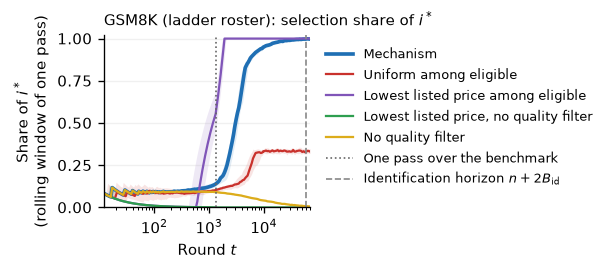

figure: analysis/results/gsm8k/ladder/long_horizon_i_star_identification_probability.pdf


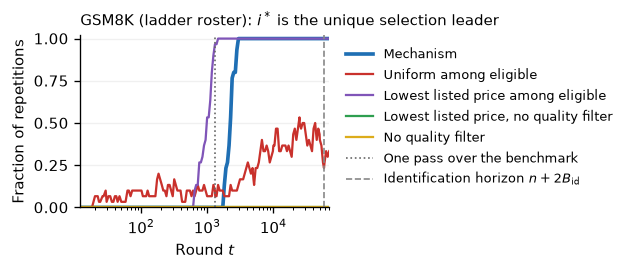

legend: analysis/results/gsm8k/ladder/legend_policies_lines.pdf


In [16]:
# Figures: rolling selection share of i*, and the probability that i* is the unique leader.
# Panels are saved without legends; `legend_policies_lines.pdf` is shared by every all-policy trajectory.
def long_band(ax, name, key, *, per_round=False):
    values = np.array([r[key] for r in LONG[name]], dtype=float)
    if per_round:
        values = values / GRID
    color, width = STYLE[name]["color"], 2.2 if name == "mechanism" else 1.35
    ax.plot(GRID, np.median(values, axis=0), color=color, linewidth=width, label=STYLE[name]["label"])
    ax.fill_between(GRID, np.percentile(values, 10, axis=0), np.percentile(values, 90, axis=0), color=color, alpha=0.13, linewidth=0)


def long_marks(ax):
    ax.axvline(ONE_PASS, color="#666", linestyle=":", linewidth=1, label="One pass over the benchmark")
    if TC.reachable:
        ax.axvline(TC.need, color="#888", linestyle="--", linewidth=1, label="Identification horizon $n + 2B_{\\mathrm{id}}$")
    ax.set_xscale("log")
    ax.set_xlim(N, T_LONG)
    ax.set_xlabel("Round $t$")


def long_figure(key, ylabel, title, name, *, per_round=False, log_y=False, ylim=None, policies=LONG_POLICIES, lines=()):
    fig, ax = plt.subplots(figsize=PANEL)
    for policy in policies:
        long_band(ax, policy, key, per_round=per_round)
    long_marks(ax)
    for value, label, above in lines:
        hline(ax, value, label, style=":", above=above)
    if log_y:
        ax.set_yscale("log")
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    finish(fig, name, title=title)


long_figure("rolling_istar_share", "Share of $i^*$\n(rolling window of one pass)",
            f"{BENCHMARK} ({ROSTER} roster): selection share of $i^*$", "long_horizon_rolling_i_star_share", ylim=(0, 1.02))

fig, ax = plt.subplots(figsize=PANEL)
for name in LONG_POLICIES:
    probability = np.mean([r["leader_is_istar"] for r in LONG[name]], axis=0)
    ax.plot(GRID, probability, color=STYLE[name]["color"], linewidth=2.2 if name == "mechanism" else 1.35, label=STYLE[name]["label"])
long_marks(ax)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Fraction of repetitions")
finish(fig, "long_horizon_i_star_identification_probability", title=f"{BENCHMARK} ({ROSTER} roster): $i^*$ is the unique selection leader")

save_legend([(policy_line(name), STYLE[name]["label"]) for name in LONG_POLICIES] + VLINES[:1 + bool(TC.reachable)],
            "policies_lines", ncol=2)

figure: analysis/results/gsm8k/ladder/long_horizon_eligible_providers.pdf


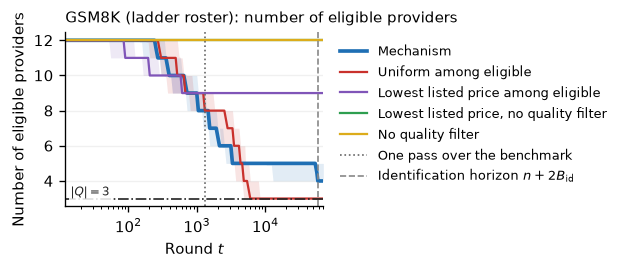

figure: analysis/results/gsm8k/ladder/long_horizon_unqualified_share.pdf


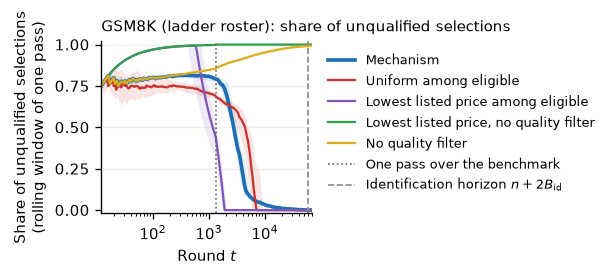

figure: analysis/results/gsm8k/ladder/long_horizon_generation_cost_per_query.pdf


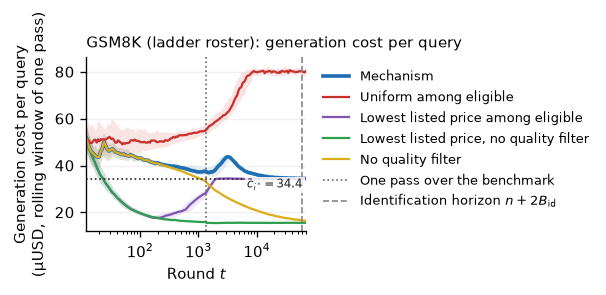

In [17]:
# Figures: number of eligible providers, share of unqualified selections and generation cost per
# query of every rule, the last two in a rolling window of one pass. Reference values are
# annotated inside the panels. The two rules without a quality filter coincide at n.
fig, ax = plt.subplots(figsize=PANEL)
for name in LONG_POLICIES:
    long_band(ax, name, "n_eligible")
long_marks(ax)
hline(ax, len(TRUTH.qualified), f"$|Q| = {len(TRUTH.qualified)}$", style="-.", where=0.02)
ax.set_ylabel("Number of eligible providers")
finish(fig, "long_horizon_eligible_providers", title=f"{BENCHMARK} ({ROSTER} roster): number of eligible providers")

long_figure("rolling_unqualified_share", "Share of unqualified selections\n(rolling window of one pass)",
            f"{BENCHMARK} ({ROSTER} roster): share of unqualified selections", "long_horizon_unqualified_share", ylim=(-0.02, 1.02))

lines = [(TRUTH.c_star, f"$\\bar c_{{i^*}} = {TRUTH.c_star:.1f}$", False)]
if LOWEST_PRICE_QUALIFIED != TRUTH.istar:
    lines.append((TRUTH.c[LOWEST_PRICE_QUALIFIED], f"cheapest listed qualified: {TRUTH.c[LOWEST_PRICE_QUALIFIED]:.1f}", True))
long_figure("rolling_generation_cost", "Generation cost per query\n(µUSD, rolling window of one pass)",
            f"{BENCHMARK} ({ROSTER} roster): generation cost per query", "long_horizon_generation_cost_per_query", lines=lines)

In [18]:
# Table: means over repetitions at the checkpoints. Regrets are per round; the leader column is
# the fraction of repetitions in which i* is the unique selection leader.
at = {int(t): int(np.flatnonzero(GRID == t)[0]) for t in CHECKPOINTS}
CHECKPOINT_KEYS = [
    "istar_share", "rolling_istar_share", "unqualified_share", "quality_regret_per_round", "generation_regret_per_round",
    "generation_cost_per_query", "query_price_per_query", "amount_paid_per_query", "excess_payment_per_round",
    "leader_is_istar", "n_eligible",
]


def checkpoint_value(record, key, k):
    if key.endswith("_per_round"):
        base = record[key.removesuffix("_per_round")]
        return None if base is None else base[k] / GRID[k]
    value = record[key]
    return None if value is None else value[k]


header = ["policy", "role", "amount paid basis", "round", *CHECKPOINT_KEYS]
rows = []
for name in LONG_POLICIES:
    for t in CHECKPOINTS:
        values = []
        for key in CHECKPOINT_KEYS:
            available = [checkpoint_value(r, key, at[t]) for r in LONG[name]]
            available = [v for v in available if v is not None]
            values.append(float(np.mean(available)) if available else "")
        rows.append([name, ROLE[name], LONG[name][0]["amount_paid_basis"], t, *values])
show(["policy", "round", *CHECKPOINT_KEYS], [[row[0], *row[3:]] for row in rows])
save_table(header, rows, "long_horizon_checkpoints")

                policy  round  istar_share  rolling_istar_share  unqualified_share  quality_regret_per_round  generation_regret_per_round  generation_cost_per_query  query_price_per_query  amount_paid_per_query  excess_payment_per_round  leader_is_istar  n_eligible
             mechanism     12       0.0833               0.0833             0.7500                    0.1754                      21.5239                    51.8601                64.8251               300.0320                  231.2876           0.0000     12.0000
             mechanism   1319       0.1402               0.1402             0.7898                    0.1494                       9.4076                    37.7971                47.2463                40.3858                    4.1100           0.0000      7.8333
             mechanism   5000       0.5019               0.8455             0.4330                    0.0689                       7.8891                    40.2634                50.3293               

## 4. Regret and theoretical bounds

Three comparisons with the theory, all from the long-horizon run. First, the average quality and
generation regrets of every routing rule. Second, the mechanism's cumulative regrets against both
branches of the regret theorems: the anytime branch, which grows like $\sqrt{t \log t}$, and the
gap-dependent branch, which is constant in $t$; the cumulative excess payment
$E_t^{\mathrm{pay}}$ is compared with its bound in the same way. Third, the number of times the mechanism selected
each provider other than $i^*$ after initialization, against its bound $M(\varepsilon_j)$ or
$L(\Delta_j)$, and the total against $B_{\mathrm{id}}$. The bounds hold on the good event, whose
empirical frequency is reported in section 5.

figure: analysis/results/gsm8k/ladder/long_horizon_quality_regret_per_round.pdf


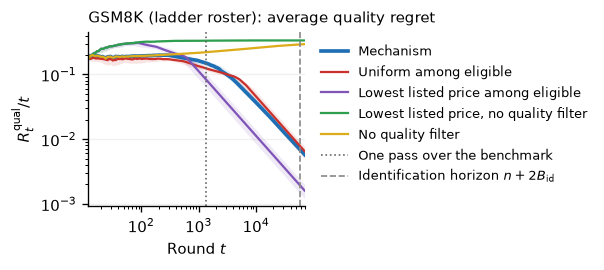

figure: analysis/results/gsm8k/ladder/long_horizon_generation_regret_per_round.pdf


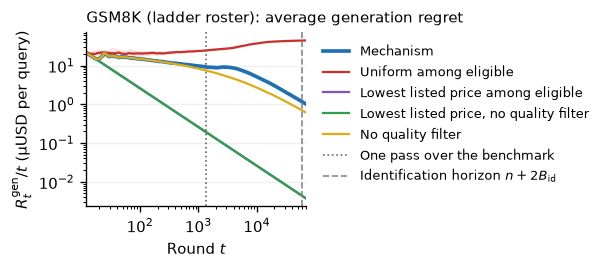

In [19]:
# Figures: average quality regret and average generation regret of every routing rule
# (cumulative regret divided by the round).
long_figure("quality_regret", "$R_t^{\\mathrm{qual}}/t$", f"{BENCHMARK} ({ROSTER} roster): average quality regret",
            "long_horizon_quality_regret_per_round", per_round=True, log_y=True)
long_figure("generation_regret", "$R_t^{\\mathrm{gen}}/t$ (µUSD per query)", f"{BENCHMARK} ({ROSTER} roster): average generation regret",
            "long_horizon_generation_regret_per_round", per_round=True, log_y=True)

figure: analysis/results/gsm8k/ladder/long_horizon_quality_regret_vs_bound.pdf


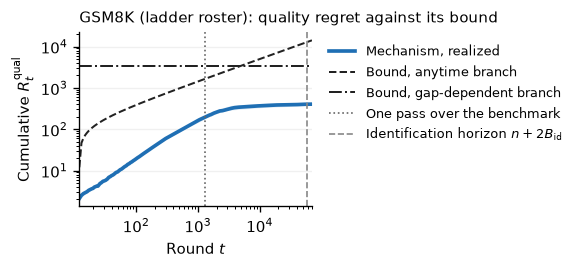

figure: analysis/results/gsm8k/ladder/long_horizon_generation_regret_vs_bound.pdf


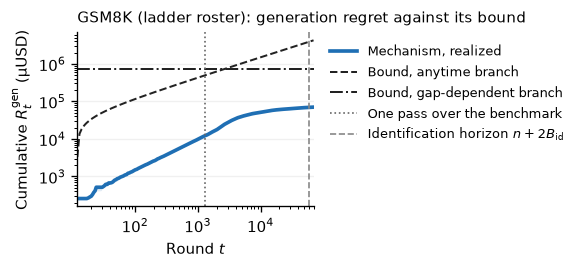

figure: analysis/results/gsm8k/ladder/long_horizon_excess_payment_vs_bound.pdf


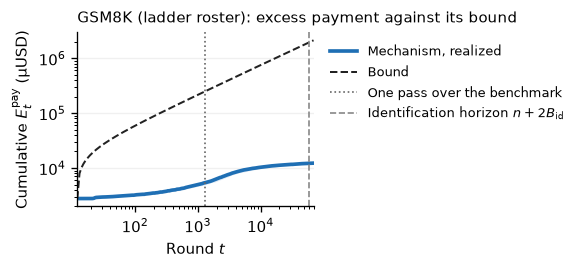

legend: analysis/results/gsm8k/ladder/legend_bounds.pdf
round  quality regret (mean)  quality bound (anytime)  quality bound (gap)  generation regret (mean)  generation bound (anytime)  generation bound (gap)  excess payment (mean)  payment bound (anytime)
   12                 2.1054                  12.0000            3348.9850                  258.2864                   3300.3520             716087.6746              2775.4513                2775.4513
 1319               197.0395                1663.3615            3348.9850                12408.6076                 498761.6528             716087.6746              5421.0851              250506.1017
 5000               344.5506                3430.1021            3348.9850                39445.7325                1028840.3590             716087.6746              9009.0466              515545.4548
10000               368.7905                4984.3432            3348.9850                51143.8427                1495162.4323            

In [20]:
# Cumulative regrets of the mechanism against the two branches of each theorem, and the
# cumulative excess payment against its bound (one branch). Bounds are evaluated on the grid.
# The three panels share `legend_bounds.pdf`.
BOUND = {key: np.array([getattr(bounds(int(t), TRUTH, RADII), key) for t in GRID])
         for key in ("quality_anytime", "quality_gap", "generation_anytime", "generation_gap", "payment_anytime")}
BOUND_STYLE = {"anytime": ("--", "Bound, anytime branch"), "gap": ("-.", "Bound, gap-dependent branch")}


def bound_figure(key, bound_prefix, ylabel, title, name, *, gap_branch=True):
    values = np.array([r[key] for r in LONG["mechanism"]], dtype=float)
    fig, ax = plt.subplots(figsize=PANEL)
    ax.plot(GRID, np.median(values, axis=0), color=STYLE["mechanism"]["color"], linewidth=2.2, label="Mechanism, realized")
    ax.fill_between(GRID, np.percentile(values, 10, axis=0), np.percentile(values, 90, axis=0),
                    color=STYLE["mechanism"]["color"], alpha=0.13, linewidth=0)
    for branch in ("anytime", "gap") if gap_branch else ("anytime",):
        style, label = BOUND_STYLE[branch]
        ax.plot(GRID, BOUND[f"{bound_prefix}_{branch}"], color="#222", linestyle=style, linewidth=1.2, label=label if gap_branch else "Bound")
    long_marks(ax)
    ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    finish(fig, name, title=title)


bound_figure("quality_regret", "quality", "Cumulative $R_t^{\\mathrm{qual}}$",
             f"{BENCHMARK} ({ROSTER} roster): quality regret against its bound", "long_horizon_quality_regret_vs_bound")
bound_figure("generation_regret", "generation", "Cumulative $R_t^{\\mathrm{gen}}$ (µUSD)",
             f"{BENCHMARK} ({ROSTER} roster): generation regret against its bound", "long_horizon_generation_regret_vs_bound")
bound_figure("excess_payment", "payment", "Cumulative $E_t^{\\mathrm{pay}}$ (µUSD)",
             f"{BENCHMARK} ({ROSTER} roster): excess payment against its bound", "long_horizon_excess_payment_vs_bound", gap_branch=False)

save_legend([
    (Line2D([], [], color=STYLE["mechanism"]["color"], linewidth=2.2), "Mechanism, realized (median)"),
    (Patch(facecolor=STYLE["mechanism"]["color"], alpha=0.25, linewidth=0), "10–90% band across repetitions"),
    (Line2D([], [], color="#222", linestyle="--", linewidth=1.2), "Bound, anytime branch"),
    (Line2D([], [], color="#222", linestyle="-.", linewidth=1.2), "Bound, gap-dependent branch"),
] + VLINES[:1 + bool(TC.reachable)], "bounds", ncol=2)

header = ["round", "quality regret (mean)", "quality bound (anytime)", "quality bound (gap)",
          "generation regret (mean)", "generation bound (anytime)", "generation bound (gap)",
          "excess payment (mean)", "payment bound (anytime)"]
rows = []
for t in CHECKPOINTS:
    k = at[t]
    rows.append([
        t, float(np.mean([r["quality_regret"][k] for r in LONG["mechanism"]])), BOUND["quality_anytime"][k], BOUND["quality_gap"][k],
        float(np.mean([r["generation_regret"][k] for r in LONG["mechanism"]])), BOUND["generation_anytime"][k], BOUND["generation_gap"][k],
        float(np.mean([r["excess_payment"][k] for r in LONG["mechanism"]])), BOUND["payment_anytime"][k],
    ])
show(header, rows)
save_table(header, rows, "long_horizon_regret_bounds")

                   provider  qualified?              gap type       gap  mean selections after initialization  max selections after initialization  mean last selection round  bound (M or L)  mean / bound
                 Llama-3-8B       False   eps_j = Theta - q_j    0.1555                              375.1667                             682.0000                  1557.8667            2809        0.1336
               Llama-3-8B@2       False   eps_j = Theta - q_j    0.1363                              540.1000                             805.0000                  3241.5667            3768        0.1433
               Llama-3-8B@4       False   eps_j = Theta - q_j    0.1277                              230.7000                             260.0000                 67171.7667            4356        0.0530
               Llama-3.2-1B       False   eps_j = Theta - q_j    0.4405                               34.6333                              71.0000                   275.4333           

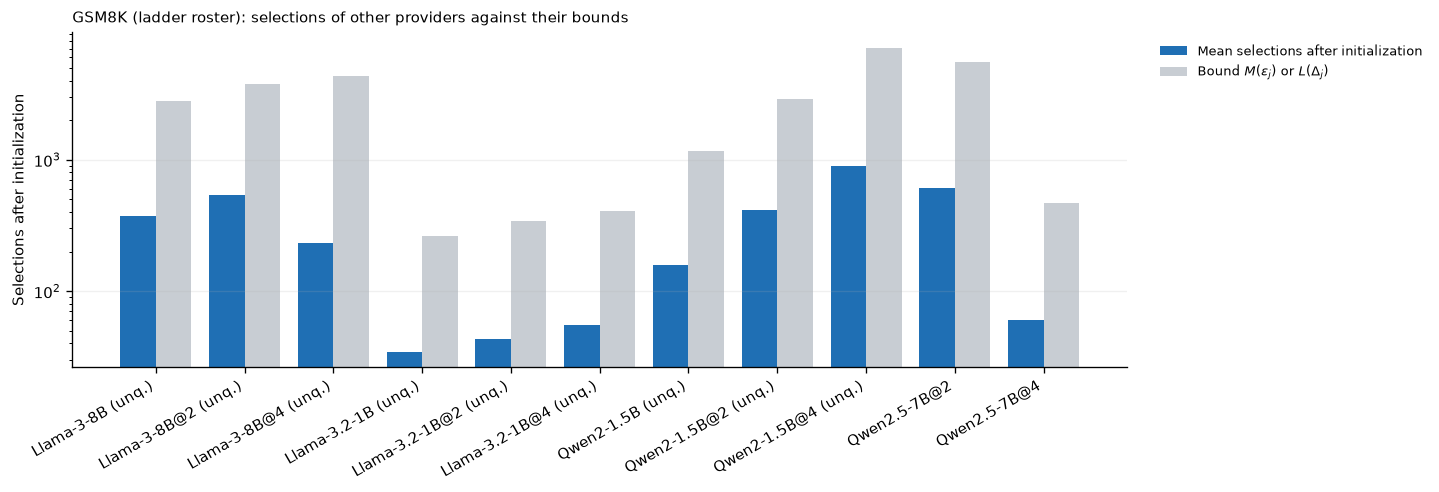

In [21]:
# Selections of every provider other than i* against M(eps_j) or L(Delta_j), and the total
# against B_id. Each provider is initialized once, so that selection is subtracted.
others = [m for m in MODELS if m != TRUTH.istar]
selection_bound = {m: provider_gap(m)[2] for m in others}
header = ["provider", "qualified?", "gap type", "gap", "mean selections after initialization", "max selections after initialization",
          "mean last selection round", "bound (M or L)", "mean / bound"]
rows = []
for model in others:
    j = INDEX[model]
    selections = np.array([r["final_counts"][j] - 1 for r in LONG["mechanism"]], dtype=float)
    last = np.array([r["last_selection_round"][j] for r in LONG["mechanism"]], dtype=float)
    gap_type, gap, bound = provider_gap(model)
    rows.append([model, model in TRUTH.qualified, gap_type, gap, float(selections.mean()), float(selections.max()),
                 float(last.mean()), bound, float(selections.mean() / bound)])
total = float(np.mean([T_LONG - r["final_counts"][ISTAR] - (N - 1) for r in LONG["mechanism"]]))
rows.append(["all providers other than i*", "", "", "", total, "", "", TC.B_id, total / TC.B_id])
show(header, rows)
save_table(header, rows, "long_horizon_selections_vs_bounds")

fig, ax = plt.subplots(figsize=(0.55 * N + 3.0, 4.0))
x = np.arange(len(others))
ax.bar(x - 0.2, [rows[i][4] for i in range(len(others))], width=0.4, color=STYLE["mechanism"]["color"], label="Mean selections after initialization")
ax.bar(x + 0.2, [selection_bound[m] for m in others], width=0.4, color="#c8cdd3", label="Bound $M(\\varepsilon_j)$ or $L(\\Delta_j)$")
ax.set_xticks(x, [m + (" (unq.)" if m not in TRUTH.qualified else "") for m in others], rotation=30, ha="right")
ax.set_yscale("log")
ax.set_ylabel("Selections after initialization")
finish(fig, "long_horizon_selections_vs_bounds", title=f"{BENCHMARK} ({ROSTER} roster): selections of other providers against their bounds")

## 5. Payments and provider outcomes

For the mechanism and the no-quality-filter ablation the amount paid is the critical payment; for
the listed-price rules it is the query price of the selected provider. The mechanism's query price
is reported only as what a listed-price platform would have paid for the same generations.
Initialization pays $C_{\max}$ by construction, so quantities are also given after initialization.
The payment-bounds lemma is checked round by round, and the good event (every empirical mean
inside its radius at every selection count) is checked for every repetition. A provider's payoff
is its total payment minus its total generation cost; it can be negative on a realization, since
participation is a statement about expected payoff.

In [22]:
# Table: the mechanism's economic quantities and payment diagnostics over the one-pass repetitions.
mechanism = [r for r in ONE if r["policy"] == "mechanism"]
PAYMENT_KEYS = [
    "generation_cost_per_query", "query_price_per_query", "mechanism_payment_per_query", "amount_paid_per_query",
    "generation_cost_per_query_post_init", "query_price_per_query_post_init", "mean_winning_bid_post_init",
    "mechanism_payment_per_query_post_init", "excess_payment_per_round", "excess_payment_per_round_post_init",
    "mean_provider_payoff", "min_provider_payoff",
]
header = ["quantity", "mean", "sd", "95% half-width", "min", "max"]
rows = []
for key in PAYMENT_KEYS:
    values = pick(mechanism, "mechanism", key)
    mean, half = mean_ci(values)
    rows.append([key, mean, sd(values), half, float(values.min()), float(values.max())])
rows += [
    ["repetitions", len(mechanism), "", "", "", ""],
    ["good event holds (count)", sum(bool(r["good_event_holds"]) for r in mechanism), "", "", "", ""],
    ["good event violations (total)", sum(r["good_event_violations"] for r in mechanism), "", "", "", ""],
    ["payment bound violations (total)", sum(r["payment_bound_violations"] for r in mechanism), "", "", "", ""],
    ["critical payment below bid (rounds)", sum(r["critical_below_bid_rounds"] for r in mechanism), "", "", "", ""],
]
show(header, rows)
save_table(header, rows, "payments_one_pass")

# The same diagnostics over the long-horizon repetitions of the paid arms.
header = ["policy", "repetitions", "good event holds (count)", "good event violations (total)",
          "critical payment below bid (rounds)", "mean provider payoff", "min provider payoff"]
rows = []
for name in LONG_POLICIES:
    paid = [r for r in LONG[name] if r["provider_payoff"] is not None]
    if not paid:
        continue
    rows.append([name, len(paid), sum(bool(r["good_event_holds"]) for r in paid), sum(r["good_event_violations"] for r in paid),
                 sum(r["critical_below_bid_rounds"] for r in paid),
                 float(np.mean([np.mean(list(r["provider_payoff"].values())) for r in paid])),
                 float(min(min(r["provider_payoff"].values()) for r in paid))])
show(header, rows)
save_table(header, rows, "payments_long_horizon_diagnostics")

                             quantity      mean        sd  95% half-width        min       max
            generation_cost_per_query   37.7971    1.4048          0.5027    35.2179   41.8839
                query_price_per_query   47.2463    1.7560          0.6284    44.0224   52.3549
          mechanism_payment_per_query   40.3858    1.4938          0.5345    37.6110   44.6890
                amount_paid_per_query   40.3858    1.4938          0.5345    37.6110   44.6890
  generation_cost_per_query_post_init   37.6679    1.4183          0.5075    35.0899   41.7973
      query_price_per_query_post_init   47.0849    1.7729          0.6344    43.8624   52.2466
           mean_winning_bid_post_init   37.5942    1.5061          0.5389    34.7990   41.9318
mechanism_payment_per_query_post_init   38.0019    1.5075          0.5395    35.2016   42.3446
             excess_payment_per_round    4.1100    0.2333          0.0835     3.6004    4.5007
   excess_payment_per_round_post_init    2.0242   

In [23]:
# Table: each provider's payoff under the mechanism in one pass, over repetitions.
header = ["provider", "qualified?", "role", "mean selections", "mean payoff", "sd payoff", "min payoff", "max payoff",
          "mean payoff per selection", "repetitions with negative payoff"]
rows = []
for model in sorted(MODELS, key=lambda m: TRUTH.c[m]):
    payoff = np.array([r["provider_payoff"][model] for r in mechanism], dtype=float)
    selections = np.array([r["selection_counts"][model] for r in mechanism], dtype=float)
    rows.append([
        model, model in TRUTH.qualified,
        "i*" if model == TRUTH.istar else "qualified" if model in TRUTH.qualified else "unqualified",
        float(selections.mean()), float(payoff.mean()), sd(payoff), float(payoff.min()), float(payoff.max()),
        float(payoff.sum() / selections.sum()), int((payoff < 0).sum()),
    ])
show(header, rows)
save_table(header, rows, "provider_payoffs_one_pass")

      provider  qualified?         role  mean selections  mean payoff  sd payoff  min payoff  max payoff  mean payoff per selection  repetitions with negative payoff
    Qwen2-1.5B       False  unqualified         160.2667     324.6326    76.0297    214.4744    522.6115                     2.0256                                 0
  Llama-3.2-1B       False  unqualified          35.6333     317.8239    39.1439    254.3477    430.1025                     8.9193                                 0
    Llama-3-8B       False  unqualified         269.6000     303.0928   103.9588     81.7840    456.1252                     1.1242                                 0
  Qwen2-1.5B@2       False  unqualified         212.7333     302.3194   169.3147     28.9023    793.2710                     1.4211                                 0
Llama-3.2-1B@2       False  unqualified          43.9000     303.0508    70.9952    139.5228    482.8583                     6.9032                                 0
    

figure: analysis/results/gsm8k/ladder/payment_bounds_long_horizon.pdf


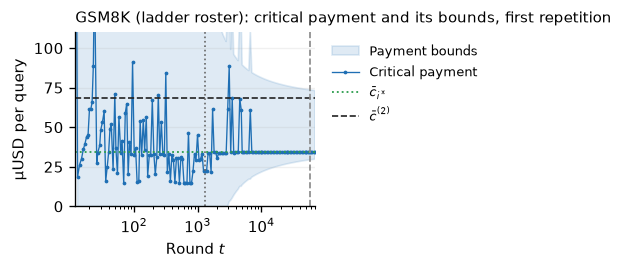

legend: analysis/results/gsm8k/ladder/legend_payment_bounds.pdf


In [24]:
# Figure: the critical payment of the first long-horizon repetition at the grid rounds, inside the
# payment bounds of the payment-bounds lemma for the provider selected in that round. The bounds
# close as selection counts grow. This panel has its own legend PDF, `legend_payment_bounds.pdf`.
first = LONG["mechanism"][0]
fig, ax = plt.subplots(figsize=PANEL)
ax.fill_between(GRID, first["bound_lower"], first["bound_upper"], color=STYLE["mechanism"]["color"], alpha=0.14, label="Payment bounds")
ax.plot(GRID, first["payment_at_grid"], color=STYLE["mechanism"]["color"], linewidth=0.8, marker=".", markersize=2.5, label="Critical payment")
ax.axhline(TRUTH.c_star, color=COLOR_ISTAR, linestyle=":", linewidth=1.1, label="$\\bar c_{i^*}$")
ax.axhline(TRUTH.c_second, color="#222", linestyle="--", linewidth=1.0, label="$\\bar c^{(2)}$")
ax.axvline(ONE_PASS, color="#666", linestyle=":", linewidth=1)
if TC.reachable:
    ax.axvline(TC.need, color="#888", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlim(N, T_LONG)
ax.set_ylim(0, 1.6 * TRUTH.c_second)   # the upper bound starts at C_max; the region of interest is around c^(2)
ax.set_xlabel("Round $t$")
ax.set_ylabel("µUSD per query")
finish(fig, "payment_bounds_long_horizon", title=f"{BENCHMARK} ({ROSTER} roster): critical payment and its bounds, first repetition")

save_legend([
    (Line2D([], [], color=STYLE["mechanism"]["color"], linewidth=0.8, marker=".", markersize=4), "Critical payment"),
    (Patch(facecolor=STYLE["mechanism"]["color"], alpha=0.25, linewidth=0), "Payment bounds"),
    (Line2D([], [], color=COLOR_ISTAR, linestyle=":", linewidth=1.1), "$\\bar c_{i^*}$"),
    (Line2D([], [], color="#222", linestyle="--", linewidth=1.0), "$\\bar c^{(2)}$"),
] + VLINES[:1 + bool(TC.reachable)], "payment_bounds", ncol=3)

figure: analysis/results/gsm8k/ladder/long_horizon_amount_paid_per_query.pdf


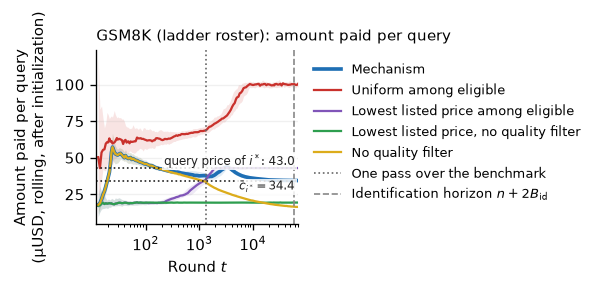

figure: analysis/results/gsm8k/ladder/long_horizon_mechanism_economic_quantities.pdf


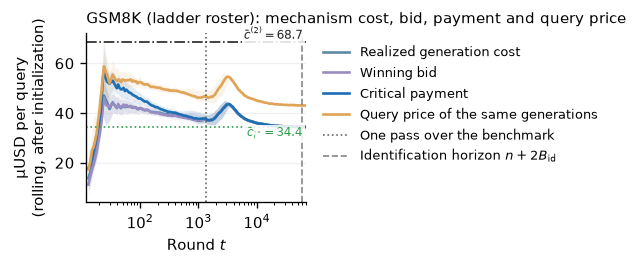

legend: analysis/results/gsm8k/ladder/legend_economic.pdf


In [25]:
# Figures: the amount the platform pays per query under every routing rule, and the mechanism's
# realized generation cost, winning bid, critical payment and query price, all in a rolling window
# of one pass over the rounds after initialization. Reference values are annotated in the panels;
# the second figure has its own legend PDF, `legend_economic.pdf`.
long_figure("rolling_amount_paid", "Amount paid per query\n(µUSD, rolling, after initialization)",
            f"{BENCHMARK} ({ROSTER} roster): amount paid per query", "long_horizon_amount_paid_per_query",
            lines=[(TRUTH.c_star, f"$\\bar c_{{i^*}} = {TRUTH.c_star:.1f}$", False),
                   (TRUTH.price[TRUTH.istar], f"query price of $i^*$: {TRUTH.price[TRUTH.istar]:.1f}", True)])

ECONOMIC = [
    ("rolling_generation_cost_after_init", "Realized generation cost", "#5d8aa8"),
    ("rolling_winning_bid", "Winning bid", "#9b8dc4"),
    ("rolling_mechanism_payment", "Critical payment", "#1f6fb4"),
    ("rolling_query_price_after_init", "Query price of the same generations", "#e0a458"),
]
fig, ax = plt.subplots(figsize=PANEL)
for key, label, color in ECONOMIC:
    values = np.array([r[key] for r in LONG["mechanism"]], dtype=float)
    ax.plot(GRID, np.nanmedian(values, axis=0), color=color, linewidth=1.6, label=label)
    ax.fill_between(GRID, np.nanpercentile(values, 10, axis=0), np.nanpercentile(values, 90, axis=0), color=color, alpha=0.13, linewidth=0)
long_marks(ax)
hline(ax, TRUTH.c_star, f"$\\bar c_{{i^*}} = {TRUTH.c_star:.1f}$", style=":", color=COLOR_ISTAR, above=False)
hline(ax, TRUTH.c_second, f"$\\bar c^{{(2)}} = {TRUTH.c_second:.1f}$", style="-.")
ax.set_ylabel("µUSD per query\n(rolling, after initialization)")
finish(fig, "long_horizon_mechanism_economic_quantities", title=f"{BENCHMARK} ({ROSTER} roster): mechanism cost, bid, payment and query price")

save_legend([(Line2D([], [], color=color, linewidth=1.6), label) for _, label, color in ECONOMIC] + VLINES[:1 + bool(TC.reachable)],
            "economic", ncol=2)

## 6. Run manifest and outputs

The manifest records the settings, seeds and definitions needed to reproduce every path, and
lists the files written to the output directory.

In [26]:
manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_value("rev-parse", "HEAD"),
    "git_worktree_dirty": bool(git_value("status", "--porcelain")),
    "benchmark": BENCHMARK,
    "roster": ROSTER,
    "environment": ENV.id,
    "quick": QUICK,
    "master_seed": MASTER,
    "draw_seed": draw_seed(MASTER, ENV.id),
    "episode_seeds": [episode_seed(MASTER, ENV.id, rep) for rep in range(max(REPS, LONG_REPS))],
    "one_pass_rounds": ONE_PASS,
    "one_pass_repetitions": REPS,
    "one_pass_policies": POLICIES,
    "long_horizon_rounds": T_LONG,
    "long_horizon_repetitions": LONG_REPS,
    "long_horizon_policies": LONG_POLICIES,
    "checkpoints": CHECKPOINTS,
    "grid": GRID.tolist(),
    "theta": ENV.theta,
    "roster_models": MODELS,
    "c_max": RADII.c_max,
    "delta": RADII.delta,
    "gamma": RADII.gamma,
    "margin_used_to_construct_costs": MARGIN,
    "monetary_unit": "1e-6 USD",
    "amount_paid_definition": {
        "mechanism_and_no_quality_filter": "critical payment under the configured payment rule",
        "listed_price_alternatives": "query price of the selected provider (generated tokens times its listed price)",
    },
    "trajectory_summary": "median over repetitions with a 10-90% band; probabilities are fractions of repetitions",
    "figures": sorted(p.name for p in OUT.glob("*.pdf") if not p.name.startswith("legend_")),
    "legends": sorted(p.name for p in OUT.glob("legend_*.pdf")),
    "tables": sorted(p.name for p in OUT.glob("*.csv") if not p.name.endswith("_per_repetition.csv")),
    "per_repetition_results": sorted(p.name for p in OUT.glob("*_per_repetition.csv")),
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("manifest:", (OUT / "manifest.json").relative_to(ROOT))
for path in sorted(OUT.iterdir()):
    print(f"  {path.name}  ({path.stat().st_size / 1024:.0f} kB)")

manifest: analysis/results/gsm8k/ladder/manifest.json
  environment.csv  (1 kB)
  legend_bounds.pdf  (19 kB)
  legend_economic.pdf  (15 kB)
  legend_landscape.pdf  (16 kB)
  legend_payment_bounds.pdf  (19 kB)
  legend_policies_lines.pdf  (19 kB)
  legend_policies_markers.pdf  (14 kB)
  long_horizon_amount_paid_per_query.pdf  (35 kB)
  long_horizon_checkpoints.csv  (9 kB)
  long_horizon_eligible_providers.pdf  (19 kB)
  long_horizon_excess_payment_vs_bound.pdf  (18 kB)
  long_horizon_final_counts_per_repetition.csv  (141 kB)
  long_horizon_generation_cost_per_query.pdf  (36 kB)
  long_horizon_generation_regret_per_round.pdf  (28 kB)
  long_horizon_generation_regret_vs_bound.pdf  (18 kB)
  long_horizon_grid_per_repetition.csv  (8609 kB)
  long_horizon_i_star_identification_probability.pdf  (14 kB)
  long_horizon_mechanism_economic_quantities.pdf  (33 kB)
  long_horizon_quality_regret_per_round.pdf  (28 kB)
  long_horizon_quality_regret_vs_bound.pdf  (16 kB)
  long_horizon_regret_bounds.c

## 7. Cross-environment summary

One table of the one-pass outcomes over every environment that has been run so far, read from
the `one_pass_outcomes.csv` and `environment.csv` files under `analysis/results/`. It is
written to `analysis/results/one_pass_summary.csv` and rebuilt on every run.

In [27]:
RESULTS = ROOT / "analysis/results"
SUMMARY_METRICS = [
    "unqualified_share", "quality_regret_per_round", "generation_regret_per_round",
    "generation_cost_per_query", "amount_paid_per_query", "istar_share",
]
header = ["benchmark", "roster", "Theta", "|Q|", "i*", "policy", "role", "amount paid basis"]
for key in SUMMARY_METRICS:
    header += [f"{key} mean", f"{key} 95% half-width"]
rows = []
for outcomes in sorted(RESULTS.glob("*/*/one_pass_outcomes.csv")):
    directory = outcomes.parent
    with (directory / "environment.csv").open() as handle:
        constants = dict(csv.reader(handle))
    with outcomes.open() as handle:
        for record in csv.DictReader(handle):
            rows.append([
                directory.parent.name, directory.name, constants["Theta"], constants["qualified providers |Q|"], constants["i*"],
                record["policy"], record["role"], record["amount paid basis"],
                *[float(record[f"{key} {stat}"]) for key in SUMMARY_METRICS for stat in ("mean", "95% half-width")],
            ])
show(["benchmark", "roster", "policy", *SUMMARY_METRICS], [[row[0], row[1], row[5], *row[8::2]] for row in rows])
path = RESULTS / "one_pass_summary.csv"
with path.open("w", newline="") as handle:
    csv.writer(handle).writerows([header, *rows])
print("table:", path.relative_to(ROOT))

benchmark  roster                  policy  unqualified_share  quality_regret_per_round  generation_regret_per_round  generation_cost_per_query  amount_paid_per_query  istar_share
    gsm8k    full               mechanism             0.7337                    0.1054                       2.8308                    17.6052                18.2143       0.1885
    gsm8k    full        uniform_eligible             0.5978                    0.0939                       7.0493                    22.5176                28.1470       0.1364
    gsm8k    full  cheapest_rate_eligible             0.0045                    0.0010                       0.0402                    16.1169                20.1461       0.9939
    gsm8k    full          cheapest_price             0.0045                    0.0010                       0.0402                    16.1169                20.1461       0.9939
    gsm8k    full       no_quality_filter             0.7991                    0.1820                   